# Derivatives 2 notebook

## Automatic differentiation

List of potential operations on the state vector $[x,x']$ of the form:

$$
x \rightarrow U(x) : [x,x'] \rightarrow [U(x),U_x(x)x']
$$

- $x \rightarrow x+c : [x,x'] \rightarrow [x+c,x']$
- $x \rightarrow cx : [x,x'] \rightarrow [cx,cx']$
- $x \rightarrow x^c : [x,x'] \rightarrow [x^c,cx^{c-1}x']$
- $x \rightarrow c^x : [x,x'] \rightarrow [c^x,c^x\ln(c)x']$
- $x \rightarrow \ln(x) : [x,x'] \rightarrow [\ln(x),x'/x]$
- $x \rightarrow \sin(x) : [x,x'] \rightarrow [\sin(x),\cos(x)x']$
- $x \rightarrow \cos(x) : [x,x'] \rightarrow [\cos(x),-\sin(x)x']$
- $x \rightarrow \tan(x) : [x,x'] \rightarrow [\tan(x),x'/\cos^2(x)]$
- etc.

List of potential operations on state vectors $[x,x']$ and $[y,y']$ of the form:

$$
x,y \rightarrow B(x,y) : [x,x'][y,y']\rightarrow [B(x,y), B_x(x,y)x' + B_y(x,y)y']
$$

where 

$$
B_x(x,y) = \frac{\partial B}{\partial x}
$$

and

$$
B_y(x,y) = \frac{\partial B}{\partial y}
$$

- $x,y \rightarrow x+y : [x,x'][y,y'] \rightarrow [x+y, x'+y']$
- $x,y \rightarrow x-y : [x,x'][y,y'] \rightarrow [x-y, x'-y']$
- $x,y \rightarrow xy : [x,x'][y,y'] \rightarrow [xy, yx'+ xy']$
- $x,y \rightarrow x/y : [x,x'][y,y'] \rightarrow [x+y, x'/y-xy'/y^2]$
- $x,y \rightarrow x^y : [x,x'][y,y'] \rightarrow [x^y, yx^{y-1}x'+x^y\ln(x)y']$
- etc.

## Example

Consider the function:

$$
f(x) = \frac{x^2}{e^{3x}+1}
$$

Evaluate it from 0 to 2 without any approximation.

We must break it into parts:

$$
u_1 = e^{3x}
$$

$$
u_2 = u_1 + 1
$$

$$
u_3 = x^2
$$

$$
u_4 = \frac{u_3}{u_2}
$$

So that:

$$
f(x) = u_4(x)
$$

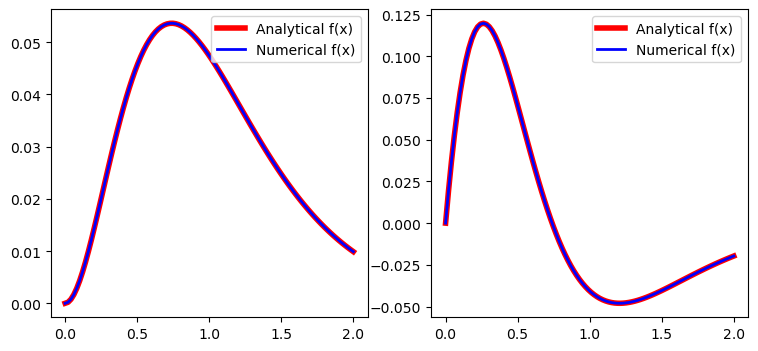

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 

# Variable x represents state vector [vx, dx]

# Reference functions calculated analytically to compare to automatic method
def ref_fx(x):
    return x**2/(np.exp(3*x)+1)

def ref_dfx(x):
    return 2*x/(np.exp(3*x)+1) - 3*np.exp(3*x)*x**2/(np.exp(3*x)+1)**2

# Create the function for automatic differentiation
def power(x,c):
    vx, dx = x
    return [vx**c, c*vx**(c-1)*dx]

def add(x, c):
    vx, dx = x
    return [vx + c, dx]

def exponential(x, c):
    vx, dx = x
    return [np.exp(c*vx), c*np.exp(c*vx)*dx]

def divide(x,y):
    vx, dx = x
    vy, dy = y
    return [vx/vy, dx/vy - vx*dy/vy**2]

def f(x):
    u1 = exponential(x,3)
    u2 = add(u1, 1)
    u3 = power(x,2)
    u4 = divide(u3,u2)
    return u4

# Run test
N = 100
ref_x = np.linspace(0.0, 2.0, num=N)
x = [[1.0,1.0]]
for i, t in enumerate(ref_x):
    if i == 0:
        x = [[t,1.0]]
    else:
        x.append([t,1.0])

ref_func = ref_fx(ref_x)
ref_der = ref_dfx(ref_x)
num_func = np.zeros(N)
num_der = np.zeros(N)

for i in range(N):
    num_func[i], num_der[i] = f(x[i])

fig = plt.figure(figsize=(9,4))
ax1 = fig.add_subplot(121)
ax1.plot(ref_x, ref_func, color='r', linewidth=4, label="Analytical f(x)")
ax1.plot(ref_x, num_func, color='b', linewidth=2, label="Numerical f(x)")
ax1.legend(loc='upper right')
ax2 = fig.add_subplot(122)
ax2.plot(ref_x, ref_der, color='r', linewidth=4, label="Analytical df(x)/dx")
ax2.plot(ref_x, num_der, color='b', linewidth=2, label="Numerical df(x)/dx")
ax2.legend(loc='upper right')

The agreement is excellent. We can also look at specific point for more precise comparison.

In [38]:
X = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for x in X:
    ref_func = ref_fx(x)
    ref_der = ref_dfx(x)
    num_func, num_der = f([x,1])

    print(f"At x = {x}, error in numerical function is {np.abs(ref_func-num_func):.6e}, and error in numerical derivative is {np.abs(ref_der-num_der):.6e}.")

At x = 0.5, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
At x = 1.0, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
At x = 1.5, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
At x = 2.0, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
At x = 2.5, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
At x = 3.0, error in numerical function is 0.000000e+00, and error in numerical derivative is 0.000000e+00.
